In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from pyproj import CRS
from geopy.geocoders import Nominatim
from geopy.distance import geodesic


In [3]:
# Tabular data
snow_df = pd.read_csv(r"C:\Users\Trish\Documents\CMU\INFO VIZ\CMU-MS-DAS-Vis-S26\data\snowstorm_PA.tsv", sep="\t")
cities_df = pd.read_csv(r"C:\Users\Trish\Documents\CMU\INFO VIZ\CMU-MS-DAS-Vis-S26\data\PA_cities_counties.tsv", sep="\t")

# Geospatial data
counties_gdf = gpd.read_file("tl_2021_us_county.zip")
muni_gdf = gpd.read_file("PaMunicipalities2022_01.zip")


In [ ]:
def add_area_and_label_coords(gdf):
    """
    Add area (in projected units) and label coordinates (centroid or representative_point) to gdf.
    Assumes gdf is already in an appropriate projected CRS.
    """
    gdf = gdf.copy()
    gdf["area"] = gdf.geometry.area
    gdf["coords"] = gdf.geometry.representative_point().apply(lambda p: (p.x, p.y))
    return gdf


def plot_with_labels(gdf, column=None, cmap="viridis", missing_kw=None, ax=None):
    """
    Plot a GeoDataFrame with optional coloring by `column` and text labels at coords.
    Assumes gdf has a 'coords' column with (x, y) tuples.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    else:
        fig = ax.figure

    plot_kwargs = {}
    if column is not None:
        plot_kwargs["column"] = column
        plot_kwargs["cmap"] = cmap
        if missing_kw is not None:
            plot_kwargs.update(missing_kw)

    gdf.plot(ax=ax, **plot_kwargs)

    for idx, row in gdf.iterrows():
        if "coords" in row and row["coords"] is not None:
            x, y = row["coords"]
            ax.text(x, y, str(idx), fontsize=6)

    ax.set_axis_off()
    return fig, ax


def calc_overall_centroid(gdf):
    """
    Return the centroid (Point) of the union of all geometries in gdf.
    """
    return gdf.unary_union.centroid


def haversine_np(lon1, lat1, lon2, lat2, earth_radius_km=6371.0):
    """
    Vectorized haversine distance in km between two sets of lon/lat coords (in degrees).
    Returns distance in kilometers.
    """
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))

    return earth_radius_km * c


In [ ]:
pa_counties = counties_gdf[counties_gdf["STATEFP"] == "42"].copy()

# Overall centroid of PA
pa_centroid = calc_overall_centroid(pa_counties)

# Orthographic projection centered on PA
ortho_crs = CRS.from_proj4(
    f"+proj=ortho +lat_0={pa_centroid.y} +lon_0={pa_centroid.x} +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
)

# Reproject geodata
pa_counties_ortho = pa_counties.to_crs(ortho_crs)
muni_ortho = muni_gdf.to_crs(ortho_crs)

pa_counties_ortho = add_area_and_label_coords(pa_counties_ortho)
muni_ortho = add_area_and_label_coords(muni_ortho)


In [ ]:
# Standardize city name
snow_df["Location_std"] = snow_df["Location"].str.strip()
cities_df["Name_std"] = cities_df["Name"].str.strip()

# Left-merge snowfall with city–county info on city name
snow_cities = snow_df.merge(
    cities_df,
    left_on="Location_std",
    right_on="Name_std",
    how="left",
    suffixes=("", "_cities"),
)

In [ ]:
geolocator = Nominatim(user_agent="pa_snowstorm_assignment")

def get_county_from_geocoder(place):
    """
    Given a city name, try to infer the county name using Nominatim.
    Returns county name string or None.
    """
    if pd.isna(place) or not str(place).strip():
        return None

    query = f"{place} Pennsylvania US"

    try:
        loc = geolocator.geocode(query, addressdetails=True, timeout=10)
    except Exception:
        return None

    if loc is None:
        return None

    # addressdetails: try to use the 'county' field
    addr = loc.raw.get("address", {})
    county = addr.get("county")
    if county:
        county = county.replace(" County", "").strip()
        return county
    display = str(loc)
    parts = [p.strip() for p in display.split(",")]
    for part in parts:
        if "County" in part:
            county_name = part.replace("County", "").strip()
            return county_name.split()[0]
    return None


# Fill missing county info
mask_no_county = snow_cities["County"].isna()
snow_cities.loc[mask_no_county, "County"] = snow_cities.loc[mask_no_county, "Location_std"].apply(
    get_county_from_geocoder
)


In [ ]:
snow_cities_clean = snow_cities[["County", "Expected Snowfall"]].copy()
snow_cities_clean = snow_cities_clean.dropna(subset=["County"])
snow_cities_clean["County"] = snow_cities_clean["County"].str.strip()

# Compute county-mean expected snowfall
county_snow = snow_cities_clean.groupby("County", as_index=False)["Expected Snowfall"].mean()
county_snow.rename(columns={"Expected Snowfall": "Expected_Snowfall"}, inplace=True)

In [ ]:
pa_counties_ortho["County_name"] = pa_counties_ortho["NAME"].str.strip()
pa_counties_snow = pa_counties_ortho.merge(
    county_snow,
    left_on="County_name",
    right_on="County",
    how="left",
)

# NaN for counties with no snowfall data
pa_counties_snow.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,...,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,area,coords,County_name,County,Expected_Snowfall
0,42,007,01214112,42007,Beaver,Beaver County,06,H1,G4020,430,...,1125854819,24162295,+40.6841401,-080.3507209,"POLYGON ((-206581.419 -37094.784, -207752.440 ...",1.149374e+09,"(-210882.71859735332, -22431.882641854703)",Beaver,Beaver,12.5
1,42,053,01213669,42053,Forest,Forest County,06,H1,G4020,None,...,1106595595,8369675,+41.5133040,-079.2497050,"POLYGON ((-93445.476 70427.948, -93446.569 703...",1.114710e+09,"(-116646.68306772478, 65246.30575079772)",Forest,NaN,NaN
2,42,117,01209189,42117,Tioga,Tioga County,06,H1,G4020,None,...,2936765818,8279717,+41.7668593,-077.2572881,"POLYGON ((52342.532 72233.690, 52327.934 72233...",2.944598e+09,"(48970.57489946001, 96966.23236150903)",Tioga,NaN,NaN
3,42,043,01213667,42043,Dauphin,Dauphin County,06,H1,G4020,276,...,1359407363,86209037,+40.4125646,-076.7926343,"POLYGON ((106061.119 -70581.796, 106064.151 -7...",1.445418e+09,"(85107.80737784017, -55687.08531436353)",Dauphin,NaN,NaN
4,42,127,01213692,42127,Wayne,Wayne County,06,H1,G4020,None,...,1879734030,64785676,+41.6466021,-075.2924932,"POLYGON ((212491.902 55357.955, 212479.069 553...",1.943266e+09,"(214237.38475126686, 82642.38450184862)",Wayne,NaN,NaN


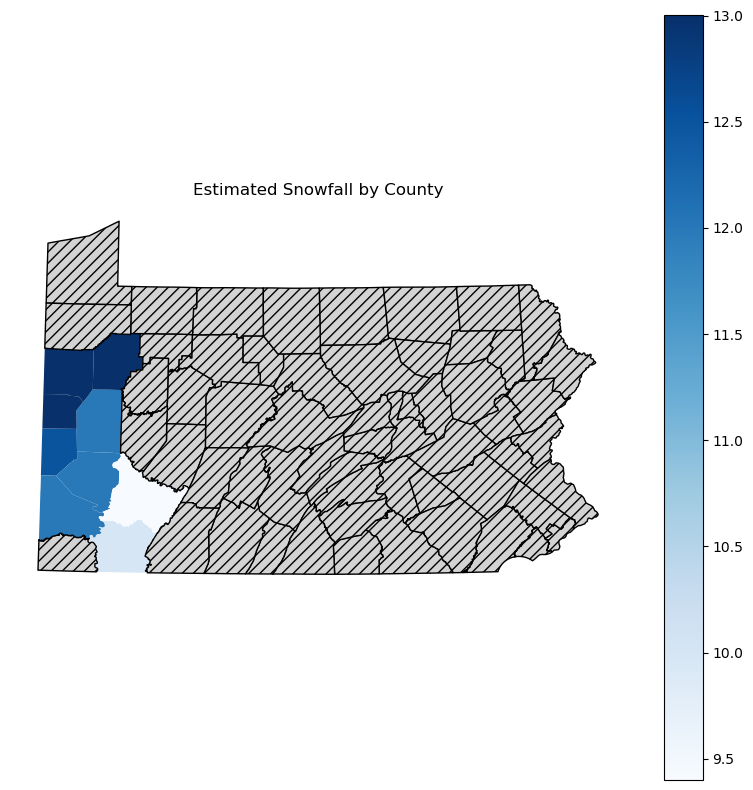

In [29]:
fig, ax = plt.subplots(figsize=(8, 8))
pa_counties_snow.plot(column="Expected_Snowfall", cmap="Blues", legend=True, ax=ax, 
                     missing_kwds={"color": "lightgrey", "edgecolor": "black", "hatch": "///"})
ax.set_title("Estimated Snowfall by County")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [ ]:
travel_towns = [
    "Pittsburgh",
    "Scranton",
    "Allentown",
    "Philadelphia",
    "Harrisburg",
    "Pittsburgh",
]

# Filter municipalities
muni_gdf["muni_lower"] = muni_gdf["MUNICIPAL1"].str.lower().str.strip()
travel_lower = [t.lower() for t in travel_towns]

travel_muni = muni_gdf[muni_gdf["muni_lower"].isin(travel_lower)].copy()

# Platte Carree projection for haversine
muni_pc = travel_muni.to_crs(epsg=4326)
muni_pc = add_area_and_label_coords(muni_pc)

# Orthographic projection for planar
muni_travel_ortho = travel_muni.to_crs(ortho_crs)
muni_travel_ortho = add_area_and_label_coords(muni_travel_ortho)

C:\Users\Trish\AppData\Local\Temp\ipykernel_46376\4134673223.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["area"] = gdf.geometry.area


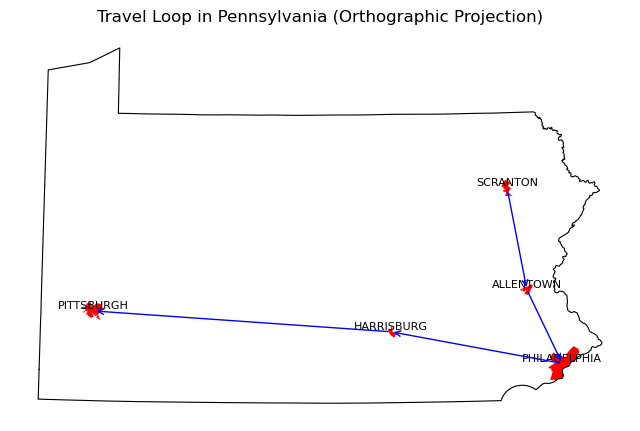

In [ ]:
# Subset PA geometry in ortho CRS just once
pa_outline = pa_counties_ortho.dissolve(by="STATEFP")

fig, ax = plt.subplots(figsize=(8, 8))

# Plot PA outline
pa_outline.boundary.plot(ax=ax, color="black", linewidth=0.8)
muni_travel_ortho.plot(ax=ax, color="red", markersize=20)

# Add labels at coords
for idx, row in muni_travel_ortho.iterrows():
    x, y = row["coords"]
    name = row["MUNICIPAL1"]
    ax.text(x, y, name, fontsize=8, ha="center", va="bottom")

# Ensure travel_muni is ordered according to travel_towns
order_map = {name.lower(): i for i, name in enumerate(travel_towns)}
muni_travel_ortho["order"] = muni_travel_ortho["muni_lower"].map(order_map)
muni_travel_ortho = muni_travel_ortho.sort_values("order")

coords = list(muni_travel_ortho["coords"])

for (x1, y1), (x2, y2) in zip(coords[:-1], coords[1:]):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", color="blue", lw=1),
    )

ax.set_title("Travel Loop in Pennsylvania (Orthographic Projection)")
ax.set_axis_off()
plt.show()

In [35]:
# Use centroids for distance
muni_travel_ortho["center"] = muni_travel_ortho.geometry.centroid

# Build ordered sequence of Points
ordered_ortho = muni_travel_ortho.sort_values("order")
centers = list(ordered_ortho["center"])

total_distance_ortho_km = 0.0
for p1, p2 in zip(centers[:-1], centers[1:]):
    # distance in meters; convert to km
    total_distance_ortho_km += p1.distance(p2) / 1000.0

print(f"Total loop distance (orthographic, km): {total_distance_ortho_km:.2f}")

Total loop distance (orthographic, km): 577.91


In [ ]:
# Extract lon/lat from centroids
ordered_pc["center"] = ordered_pc.geometry.centroid
ordered_pc["lon"] = ordered_pc["center"].x
ordered_pc["lat"] = ordered_pc["center"].y

# Clean up the temp column
ordered_pc.drop("center", axis=1, inplace=True)

total_distance_haversine_km = 0.0
for i in range(len(ordered_pc) - 1):
    lon1, lat1 = ordered_pc.iloc[i][["lon", "lat"]]
    lon2, lat2 = ordered_pc.iloc[i + 1][["lon", "lat"]]
    total_distance_haversine_km += haversine_np(lon1, lat1, lon2, lat2)

print(f"Total loop distance (haversine, km): {total_distance_haversine_km:.2f}")

Total loop distance (haversine, km): 577.17


C:\Users\Trish\AppData\Local\Temp\ipykernel_46376\668455031.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ordered_pc["center"] = ordered_pc.geometry.centroid


The differences between the projection and the orthographic projection differs by a small amount. Firstly, Platte carree projects by stretching distance as you go towards the poles and Haversine assumes the earth is a perfect sphere. So what happens is that the curve of the earth is underestimated with this combination and so we get a shorther line where the arc is shorter. This is the reason why the resulting distance from the haversine calculation is shorter compared to the orthographic projection.